# MultiModal RAG System

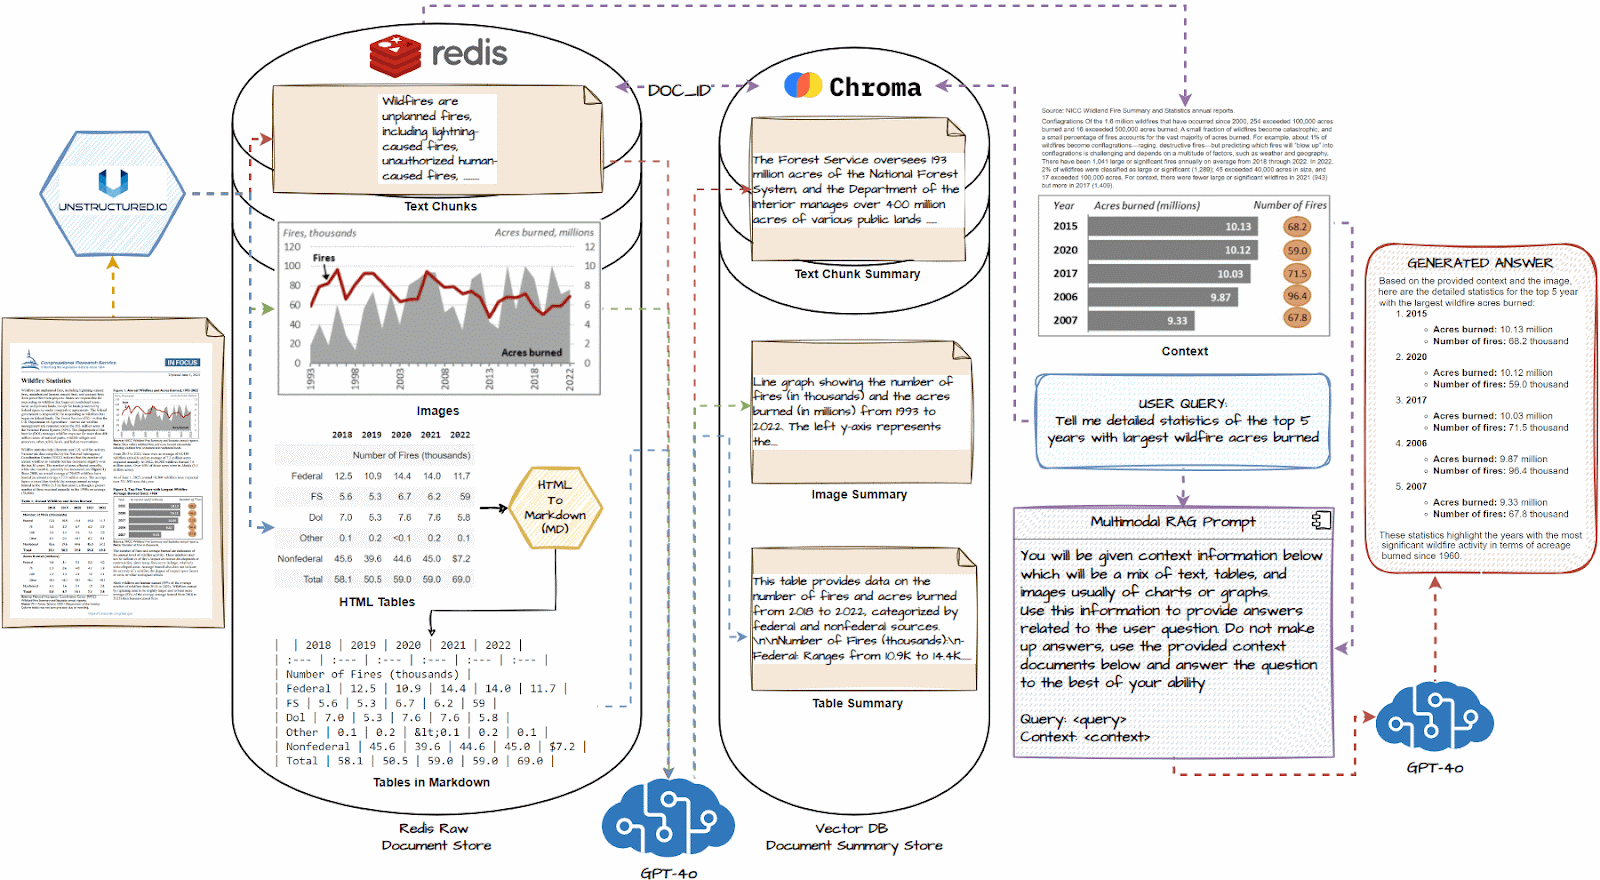

In [5]:
# %pip install redis nltk
# %pip install "unstructured[pdf]==0.16.11"
# %pip install htmltabletomd
# %pip install tesseract-ocr poppler-utils
# %pip install "pdfminer.six==20221105"
# %pip install pytesseract

In [19]:
# import nltk # NATURAL LANGUAGE TOOLKIT PACKAGE
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger')

In [ ]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\YashwanthKumar\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"

In [1]:
from langchain_community.document_loaders import UnstructuredPDFLoader

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Create chunks by loading the document using UnstructuredPDFLoader

In [ ]:
document = '../Datasets/multi_modal_rag_document.pdf'

loader = UnstructuredPDFLoader(file_path=document,
                               strategy='hi_res',
                               extract_images_in_pdf=True,
                               infer_table_structure=True,
                               mode='elements',
                               image_output_dir_path='/content/figures')
loader

In [3]:
data = loader.load()

Loading weights: 100%|██████████| 367/367 [00:00<00:00, 3246.20it/s]


In [4]:
data

[Document(metadata={'source': '../Datasets/multi_modal_rag_document.pdf', 'coordinates': {'points': ((160.0, 1.9444444444445708), (160.0, 257.63888888888886), (1539.6944444444443, 257.63888888888886), (1539.6944444444443, 1.9444444444445708)), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2026-03-18T20:14:53', 'filetype': 'application/pdf', 'languages': ['eng'], 'page_number': 1, 'image_path': 'c:\\Users\\YashwanthKumar\\Downloads\\Yash\\Github\\GenAI-Basics\\RAG\\figures\\figure-1-1.jpg', 'file_directory': '../Datasets', 'filename': 'multi_modal_rag_document.pdf', 'category': 'Image', 'element_id': 'fb5d0643af119d5ff5a12bcc13f10414'}, page_content='a. aa = Informing the legislative debate since 1914 Congressional Research Service'),
 Document(metadata={'source': '../Datasets/multi_modal_rag_document.pdf', 'detection_class_prob': 0.5129897594451904, 'coordinates': {'points': ((1297.1708984375, 258.83209228515625), (1297.1708984375, 290.84646606

In [8]:
print(len(data))

48


In [11]:
for doc in data:
    print("\n\n-------------------")
    print(doc.metadata)
    print(doc.metadata['category'])
    print(doc.page_content)



-------------------
{'source': '../Datasets/multi_modal_rag_document.pdf', 'coordinates': {'points': ((160.0, 1.9444444444445708), (160.0, 257.63888888888886), (1539.6944444444443, 257.63888888888886), (1539.6944444444443, 1.9444444444445708)), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2026-03-18T20:14:53', 'filetype': 'application/pdf', 'languages': ['eng'], 'page_number': 1, 'image_path': 'c:\\Users\\YashwanthKumar\\Downloads\\Yash\\Github\\GenAI-Basics\\RAG\\figures\\figure-1-1.jpg', 'file_directory': '../Datasets', 'filename': 'multi_modal_rag_document.pdf', 'category': 'Image', 'element_id': 'fb5d0643af119d5ff5a12bcc13f10414'}
Image
a. aa = Informing the legislative debate since 1914 Congressional Research Service


-------------------
{'source': '../Datasets/multi_modal_rag_document.pdf', 'detection_class_prob': 0.5129897594451904, 'coordinates': {'points': ((1297.1708984375, 258.83209228515625), (1297.1708984375, 290.8464660644531)

#### Tables

In [12]:
tables = [doc for doc in data if doc.metadata['category'] == 'Table']
tables

[Document(metadata={'source': '../Datasets/multi_modal_rag_document.pdf', 'detection_class_prob': 0.9197547435760498, 'coordinates': {'points': ((165.53562927246094, 1271.2908935546875), (165.53562927246094, 1967.351318359375), (820.4866943359375, 1967.351318359375), (820.4866943359375, 1271.2908935546875)), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2026-03-18T20:14:53', 'text_as_html': '<table><thead><tr><th></th><th>2018</th><th>2019</th><th>2020</th><th>2021</th><th>2022</th></tr></thead><tbody><tr><td colspan="6">Number of Fires (thousands)</td></tr><tr><td>Federal</td><td>12.5</td><td>10.9</td><td>14.4</td><td>14.0</td><td>11.7</td></tr><tr><td>FS</td><td>5.6</td><td>5.3</td><td>6.7</td><td>6.2</td><td>59</td></tr><tr><td>DOI</td><td>7.0</td><td>5.3</td><td>7.6</td><td>7.6</td><td>5.8</td></tr><tr><td>Other</td><td>0.1</td><td>0.2</td><td>&lt;0.1</td><td>0.2</td><td>0.1</td></tr><tr><td>Nonfederal</td><td>45.6</td><td>39.6</td><td>44.6

#### Images

In [13]:
images = [doc for doc in data if doc.metadata['category'] == 'Image']
images

[Document(metadata={'source': '../Datasets/multi_modal_rag_document.pdf', 'coordinates': {'points': ((160.0, 1.9444444444445708), (160.0, 257.63888888888886), (1539.6944444444443, 257.63888888888886), (1539.6944444444443, 1.9444444444445708)), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2026-03-18T20:14:53', 'filetype': 'application/pdf', 'languages': ['eng'], 'page_number': 1, 'image_path': 'c:\\Users\\YashwanthKumar\\Downloads\\Yash\\Github\\GenAI-Basics\\RAG\\figures\\figure-1-1.jpg', 'file_directory': '../Datasets', 'filename': 'multi_modal_rag_document.pdf', 'category': 'Image', 'element_id': 'fb5d0643af119d5ff5a12bcc13f10414'}, page_content='a. aa = Informing the legislative debate since 1914 Congressional Research Service'),
 Document(metadata={'source': '../Datasets/multi_modal_rag_document.pdf', 'coordinates': {'points': ((869.9999999999999, 413.7499999999998), (869.9999999999999, 768.4722222222222), (1529.9999999999998, 768.47222222

### Create chunks only for text data

In [14]:
# Chunk text and extract text content

loader = UnstructuredPDFLoader(file_path=document,
                                strategy='hi_res',
                                extract_images_in_pdf=True,
                                infer_table_structure=True,
                                chunking_strategy="by_title", # section-based chunking
                                max_characters=4000, # max size of chunks
                                new_after_n_chars=4000, # preferred size of chunks
                                combine_text_under_n_chars=2000, # smaller chunks < 2000 chars will be combined into a large chunk
                                mode='elements',
                                image_output_dir_path='./figures')

texts = loader.load()

In [19]:
len(texts)

5

In [97]:
texts[0].metadata['orig_elements']

# texts[0].to_json()

'eJzNWG1r5DgS/iui4SCBltGbLTmwH7IJWXLHZZfNDMcxPQTZlru967aNX5LpXe6/X5XsTpye3uUm0NkLTMYqSaVSVamep/Lp94Ur3dZV/UORLS7IQqYmc1w4GifOUZVHlsbMJjSUoU6YjlyWxoslWWxdbzPbW9jz+yKt6zYrKtu7zo9Lu6uH/mHjivWmB4kQjMGeSfxUZP0GpFx7aVMXVY/7Pn3iEQtAxIP485LsRyLUQeTHoYwDfUSA62G86HZd77Z4i5+KL668b2zqFv+BibwoXb9rnJ/66Z9of7G1a/fQWG/JIr1YrT52ru1Wq3/bbvNkq37zj2Fr29Xqun6qytpm09Rq9UPRb4YE/nfV5S393nZFCnM/X/6wWuXFemhdt/+gnPLgl2a98Hev1gMc6S+6cNV68dlLu/5hW2dFXjjvfsFERJmk3HwQ7IKri1Di7gaNrYZt4lp0HN6pd1/QtQsbEGvJd+S2yut2W1Rr0m8cKd266ErbF4+OZC6ByJCuqFJHeMwVuaqrNdjZFXVlS/Kz65xt0w25d+1jAS5D7ZO3btFN6MPDPEny1HIVhTQxkaCKQbLELhc0SUIleKqUStXp8kTEOhCYCSYwPhP2gphNArAikMcEfsufZkvmepf24JuHFOLTPTRtncAyFoRwTHw8nU4W3o8NeM9l5O9DBcED+5mQ8wDd2bb1Yf6AG44FSudR5gynWcQUBEoZaiPBqc4sEzmP8zSTp37QIpaBnj1pqUwgcRwqhQ/4cDyuf1uQTMi1eucg/asos7xoHbnvIRZdDxVhHqMPRV8efUSZYKmUeUQNjxKqFLPUuMRRrTJhEgHpxk9ebKVhr2JjWBgoHBup8MEcjsf1b4tNHAom/6LYdMRCgIaqgZMqeFBetiRQFMshw7JZov8q+KKpHbqXFUNlh35Tt8VvINsAKFQHC2yVEdelttmLSN7WW9LAV9oWCUiToa1gXP8CbukCnyWTPbCmqauuSEpHoH5PY29

In [16]:
for doc in texts:
    print("\n\n-------------------")
    print(doc.metadata)
    print(doc.metadata['category'])
    print(doc.page_content)



-------------------
{'source': '../Datasets/multi_modal_rag_document.pdf', 'filetype': 'application/pdf', 'languages': ['eng'], 'last_modified': '2026-03-18T20:14:53', 'page_number': 1, 'orig_elements': 'eJzNWG1r5DgS/iui4SCBltGbLTmwH7IJWXLHZZfNDMcxPQTZlru967aNX5LpXe6/X5XsTpye3uUm0NkLTMYqSaVSVamep/Lp94Ur3dZV/UORLS7IQqYmc1w4GifOUZVHlsbMJjSUoU6YjlyWxoslWWxdbzPbW9jz+yKt6zYrKtu7zo9Lu6uH/mHjivWmB4kQjMGeSfxUZP0GpFx7aVMXVY/7Pn3iEQtAxIP485LsRyLUQeTHoYwDfUSA62G86HZd77Z4i5+KL668b2zqFv+BibwoXb9rnJ/66Z9of7G1a/fQWG/JIr1YrT52ru1Wq3/bbvNkq37zj2Fr29Xqun6qytpm09Rq9UPRb4YE/nfV5S393nZFCnM/X/6wWuXFemhdt/+gnPLgl2a98Hev1gMc6S+6cNV68dlLu/5hW2dFXjjvfsFERJmk3HwQ7IKri1Di7gaNrYZt4lp0HN6pd1/QtQsbEGvJd+S2yut2W1Rr0m8cKd266ErbF4+OZC6ByJCuqFJHeMwVuaqrNdjZFXVlS/Kz65xt0w25d+1jAS5D7ZO3btFN6MPDPEny1HIVhTQxkaCKQbLELhc0SUIleKqUStXp8kTEOhCYCSYwPhP2gphNArAikMcEfsufZkvmepf24JuHFOLTPTRtncAyFoRwTHw8nU4W3o8NeM9l5O9DBcED+5mQ8wDd2bb1Yf6AG44FSudR5gynWcQUBEoZaiPBqc4sEzmP8zSTp37QIpaBnj1pqUwgcRwqhQ/4cDyuf1uQTMi1eucg/asos7xoHbnvIRZdDx

#### Texts + Tables

In [18]:
new_data = texts + tables
new_data

[Document(metadata={'source': '../Datasets/multi_modal_rag_document.pdf', 'filetype': 'application/pdf', 'languages': ['eng'], 'last_modified': '2026-03-18T20:14:53', 'page_number': 1, 'orig_elements': 'eJzNWG1r5DgS/iui4SCBltGbLTmwH7IJWXLHZZfNDMcxPQTZlru967aNX5LpXe6/X5XsTpye3uUm0NkLTMYqSaVSVamep/Lp94Ur3dZV/UORLS7IQqYmc1w4GifOUZVHlsbMJjSUoU6YjlyWxoslWWxdbzPbW9jz+yKt6zYrKtu7zo9Lu6uH/mHjivWmB4kQjMGeSfxUZP0GpFx7aVMXVY/7Pn3iEQtAxIP485LsRyLUQeTHoYwDfUSA62G86HZd77Z4i5+KL668b2zqFv+BibwoXb9rnJ/66Z9of7G1a/fQWG/JIr1YrT52ru1Wq3/bbvNkq37zj2Fr29Xqun6qytpm09Rq9UPRb4YE/nfV5S393nZFCnM/X/6wWuXFemhdt/+gnPLgl2a98Hev1gMc6S+6cNV68dlLu/5hW2dFXjjvfsFERJmk3HwQ7IKri1Di7gaNrYZt4lp0HN6pd1/QtQsbEGvJd+S2yut2W1Rr0m8cKd266ErbF4+OZC6ByJCuqFJHeMwVuaqrNdjZFXVlS/Kz65xt0w25d+1jAS5D7ZO3btFN6MPDPEny1HIVhTQxkaCKQbLELhc0SUIleKqUStXp8kTEOhCYCSYwPhP2gphNArAikMcEfsufZkvmepf24JuHFOLTPTRtncAyFoRwTHw8nU4W3o8NeM9l5O9DBcED+5mQ8wDd2bb1Yf6AG44FSudR5gynWcQUBEoZaiPBqc4sEzmP8zSTp37QIpaBnj1pqUwgcRwqhQ/4cDyuf1uQTMi1eucg/asos7xoHbnvIRZdDxVhH

In [26]:
print(new_data[5].page_content)
new_data[5].metadata['text_as_html']

2018 2019 2020 Number of Fires (thousands) Federal 12.5 10.9 14.4 FS 5.6 5.3 6.7 DOI 7.0 5.3 7.6 2021 14.0 6.2 7.6 2022 11.7 5.9 5.8 Other 0.1 0.2 <0.1 0.2 0.1 Nonfederal 45.6 39.6 44.6 45.0 57.2 Total 58.1 50.5 59.0 59.0 69.0 Acres Burned (millions) Federal 4.6 3.1 7.1 5.2 4.0 FS 2.3 0.6 4.8 4.1 1.9 DOI 2.3 2.3 2.3 1.0 2.1 Other <0.1 <0.1 <0.1 <0.1 <0.1 Nonfederal 4.1 1.6 3.1 1.9 3.6 Total 8.8 4.7 10.1 7.1 7.6


'<table><thead><tr><th></th><th>2018</th><th>2019</th><th>2020</th><th>2021</th><th>2022</th></tr></thead><tbody><tr><td colspan="6">Number of Fires (thousands)</td></tr><tr><td>Federal</td><td>12.5</td><td>10.9</td><td>14.4</td><td>14.0</td><td>11.7</td></tr><tr><td>FS</td><td>5.6</td><td>5.3</td><td>6.7</td><td>6.2</td><td>59</td></tr><tr><td>DOI</td><td>7.0</td><td>5.3</td><td>7.6</td><td>7.6</td><td>5.8</td></tr><tr><td>Other</td><td>0.1</td><td>0.2</td><td>&lt;0.1</td><td>0.2</td><td>0.1</td></tr><tr><td>Nonfederal</td><td>45.6</td><td>39.6</td><td>44.6</td><td>45.0</td><td>$7.2</td></tr><tr><td>Total</td><td>58.1</td><td>50.5</td><td>59.0</td><td>59.0</td><td>69.0</td></tr><tr><td colspan="6">Acres Burned (millions)</td></tr><tr><td>Federal</td><td>46</td><td>3.1</td><td>7.1</td><td>5.2</td><td>40</td></tr><tr><td>FS</td><td>2.3</td><td>0.6</td><td>48</td><td>4.1</td><td>19</td></tr><tr><td>DOI</td><td>2.3</td><td>2.3</td><td>2.3</td><td>1.0</td><td>2.1</td></tr><tr><td>Other</td

#### Html Table to Markdown

In [29]:
import htmltabletomd

md_table = htmltabletomd.convert_table(new_data[5].metadata['text_as_html'])
print(md_table)

md_table = htmltabletomd.convert_table(new_data[6].metadata['text_as_html'])
print(md_table)

|  | 2018 | 2019 | 2020 | 2021 | 2022 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Number of Fires (thousands) |
| Federal | 12.5 | 10.9 | 14.4 | 14.0 | 11.7 |
| FS | 5.6 | 5.3 | 6.7 | 6.2 | 59 |
| DOI | 7.0 | 5.3 | 7.6 | 7.6 | 5.8 |
| Other | 0.1 | 0.2 | &lt;0.1 | 0.2 | 0.1 |
| Nonfederal | 45.6 | 39.6 | 44.6 | 45.0 | $7.2 |
| Total | 58.1 | 50.5 | 59.0 | 59.0 | 69.0 |
| Acres Burned (millions) |
| Federal | 46 | 3.1 | 7.1 | 5.2 | 40 |
| FS | 2.3 | 0.6 | 48 | 4.1 | 19 |
| DOI | 2.3 | 2.3 | 2.3 | 1.0 | 2.1 |
| Other | &lt;0.1 | &lt;0.1 | &lt;0.1 | &lt;0.1 | &lt;0.1 |
| Nonfederal | 4.1 | 1.6 | 3.1 | Lg | 3.6 |
| Total | 8.8 | 4.7 | 10.1 | 7.1 | 7.6 |

|  | 2019 | 2020 | 2021 | 2022 |
| :--- | :--- | :--- | :--- | :--- |
| Structures Burned | 963 | 17,904 | 5,972 | 2,717 |
| % Residences | 46% | 54% | 60% | 46% |



### Separate data into text and table elements

In [30]:
tables = []
docs = []

for doc in new_data:
    if doc.metadata['category'] == 'Table':
        tables.append(doc)
    elif doc.metadata['category' ] == 'NarrativeText':
        docs.append(doc)
    elif doc.metadata['category' ] == 'Title':
        docs.append(doc)
    elif doc.metadata['category' ] == 'FigureCaption':
        docs.append(doc)
    elif doc.metadata['category' ] == 'UncategorizedText':
        docs.append(doc)
    elif doc.metadata['category' ] == 'Header':
        docs.append(doc)
    elif doc.metadata['category' ] == 'CompositeElement':
        docs.append(doc)
        
print(len(tables))
print(len(docs))
print(tables)
print(docs)

2
5
[Document(metadata={'source': '../Datasets/multi_modal_rag_document.pdf', 'detection_class_prob': 0.9197547435760498, 'coordinates': {'points': ((165.53562927246094, 1271.2908935546875), (165.53562927246094, 1967.351318359375), (820.4866943359375, 1967.351318359375), (820.4866943359375, 1271.2908935546875)), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2026-03-18T20:14:53', 'text_as_html': '<table><thead><tr><th></th><th>2018</th><th>2019</th><th>2020</th><th>2021</th><th>2022</th></tr></thead><tbody><tr><td colspan="6">Number of Fires (thousands)</td></tr><tr><td>Federal</td><td>12.5</td><td>10.9</td><td>14.4</td><td>14.0</td><td>11.7</td></tr><tr><td>FS</td><td>5.6</td><td>5.3</td><td>6.7</td><td>6.2</td><td>59</td></tr><tr><td>DOI</td><td>7.0</td><td>5.3</td><td>7.6</td><td>7.6</td><td>5.8</td></tr><tr><td>Other</td><td>0.1</td><td>0.2</td><td>&lt;0.1</td><td>0.2</td><td>0.1</td></tr><tr><td>Nonfederal</td><td>45.6</td><td>39.6</td><td>

### Convert HTML tables to Markdown

In [33]:
for table in tables:
    table.page_content = htmltabletomd.convert_table(table.metadata['text_as_html'])
    
for table in tables:
    print(table.page_content)
    print()

|  | 2018 | 2019 | 2020 | 2021 | 2022 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Number of Fires (thousands) |
| Federal | 12.5 | 10.9 | 14.4 | 14.0 | 11.7 |
| FS | 5.6 | 5.3 | 6.7 | 6.2 | 59 |
| DOI | 7.0 | 5.3 | 7.6 | 7.6 | 5.8 |
| Other | 0.1 | 0.2 | &lt;0.1 | 0.2 | 0.1 |
| Nonfederal | 45.6 | 39.6 | 44.6 | 45.0 | $7.2 |
| Total | 58.1 | 50.5 | 59.0 | 59.0 | 69.0 |
| Acres Burned (millions) |
| Federal | 46 | 3.1 | 7.1 | 5.2 | 40 |
| FS | 2.3 | 0.6 | 48 | 4.1 | 19 |
| DOI | 2.3 | 2.3 | 2.3 | 1.0 | 2.1 |
| Other | &lt;0.1 | &lt;0.1 | &lt;0.1 | &lt;0.1 | &lt;0.1 |
| Nonfederal | 4.1 | 1.6 | 3.1 | Lg | 3.6 |
| Total | 8.8 | 4.7 | 10.1 | 7.1 | 7.6 |


|  | 2019 | 2020 | 2021 | 2022 |
| :--- | :--- | :--- | :--- | :--- |
| Structures Burned | 963 | 17,904 | 5,972 | 2,717 |
| % Residences | 46% | 54% | 60% | 46% |




### View Extracted Images

In [47]:
from IPython.display import Image, display
from glob import glob

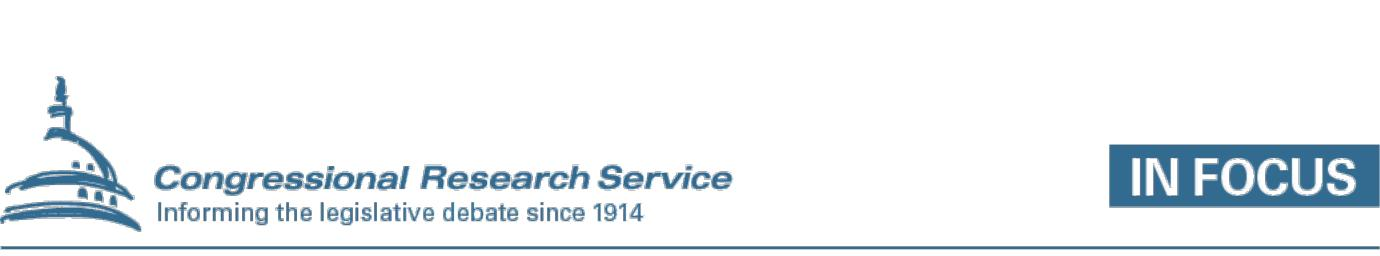

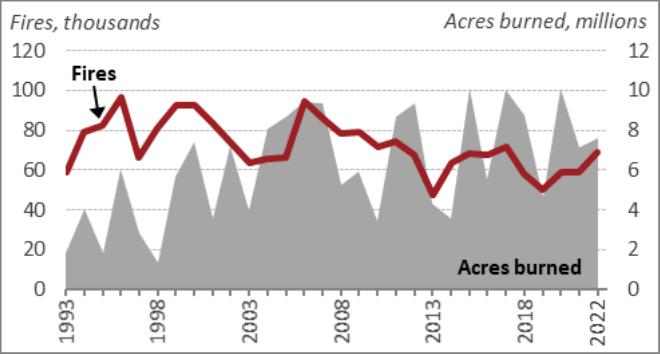

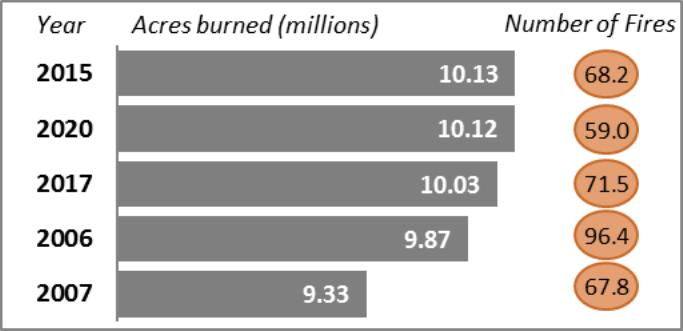

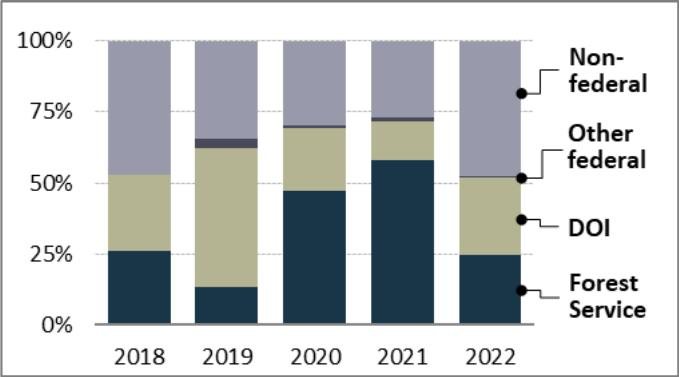

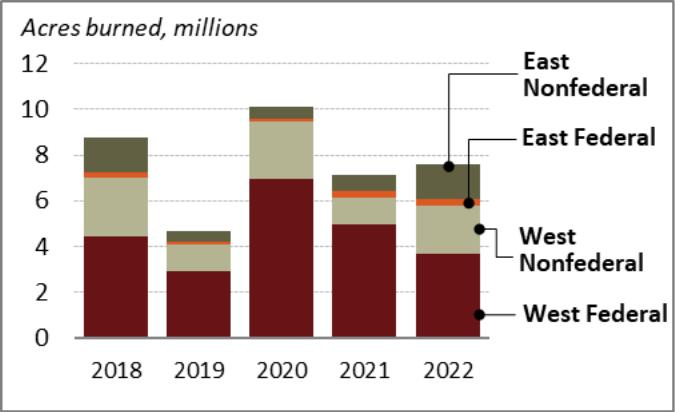

In [48]:
for path in glob("./figures/*.jpg"):
    display(Image(filename=path))

### LLM Client

In [50]:
import os
from langchain_openai import ChatOpenAI

In [51]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'), model='gpt-4o-mini', temperature=0)
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001EFB3FA7690>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001EFB417B5D0>, root_client=<openai.OpenAI object at 0x000001EFB3FA63D0>, root_async_client=<openai.AsyncOpenAI object at 0x000001EFBD8F1AD0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### Text & Table Summaries

In [52]:
# We will use GPT-4o to produce table and, text summaries.
# Text summaries are advised if using large chunk sizes (e.g., as set above, we use 4k token chunks).
# Summaries are used to retrieve raw tables and / or raw chunks of text.

In [53]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

In [54]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text particularly for semantic retrieval.
These summaries will be embedded and used to retrieve the raw text or table elements
Give a detailed summary of the table or text below that is well optimized for retrieval.
For any tables also add in a one line description of what the table is about besides the summary.
Do not add redundant words like Summary.
Just output the actual summary content.

Table or text chunk:
{element}
"""

prompt = ChatPromptTemplate.from_template(prompt_text)
prompt

ChatPromptTemplate(input_variables=['element'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['element'], input_types={}, partial_variables={}, template='\nYou are an assistant tasked with summarizing tables and text particularly for semantic retrieval.\nThese summaries will be embedded and used to retrieve the raw text or table elements\nGive a detailed summary of the table or text below that is well optimized for retrieval.\nFor any tables also add in a one line description of what the table is about besides the summary.\nDo not add redundant words like Summary.\nJust output the actual summary content.\n\nTable or text chunk:\n{element}\n'), additional_kwargs={})])

In [62]:
summarize_chain = (
    {"element": RunnablePassthrough()}
    |
    prompt
    |
    llm
    |
    StrOutputParser()
)
summarize_chain

{
  element: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['element'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['element'], input_types={}, partial_variables={}, template='\nYou are an assistant tasked with summarizing tables and text particularly for semantic retrieval.\nThese summaries will be embedded and used to retrieve the raw text or table elements\nGive a detailed summary of the table or text below that is well optimized for retrieval.\nFor any tables also add in a one line description of what the table is about besides the summary.\nDo not add redundant words like Summary.\nJust output the actual summary content.\n\nTable or text chunk:\n{element}\n'), additional_kwargs={})])
| ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'aud

In [69]:
text_summaries = []
tables_summaries = []

text_docs = [doc.page_content for doc in docs]
table_docs = [table.page_content for table in tables]

text_summaries = summarize_chain.batch(text_docs, {'max_concurrency': 5})
table_summaries = summarize_chain.batch(table_docs, {'max_concurrency': 5})

print(len(text_summaries), text_summaries)
print(len(table_summaries), table_summaries)

5 ['Wildfire statistics detail the management and impact of wildfires in the U.S., highlighting the roles of state and federal agencies. Wildfires, which include various causes such as lightning and human activity, are primarily managed by states on nonfederal lands and by federal agencies on federal lands. The U.S. Forest Service oversees wildfire management on 193 million acres, while the Department of the Interior manages over 400 million acres. Data from the National Interagency Coordination Center shows that while the number of annual wildfires has slightly decreased over the past 30 years, the acreage burned has generally increased. From 2000 to 2022, an average of 70,025 wildfires burned approximately 7.0 million acres annually, with a notable increase in acreage compared to the 1990s. In 2022, there were 68,988 wildfires affecting 7.6 million acres, with Alaska accounting for over 40% of the burned area. As of June 1, 2023, there have been around 18,300 wildfires impacting over

In [70]:
for text in (text_summaries):
    print(text)
    print("**")
    
print("---------")

for table in (table_summaries):
    print(table)
    print("**")
    

Wildfire statistics detail the management and impact of wildfires in the U.S., highlighting the roles of state and federal agencies. Wildfires, which include various causes such as lightning and human activity, are primarily managed by states on nonfederal lands and by federal agencies on federal lands. The U.S. Forest Service oversees wildfire management on 193 million acres, while the Department of the Interior manages over 400 million acres. Data from the National Interagency Coordination Center shows that while the number of annual wildfires has slightly decreased over the past 30 years, the acreage burned has generally increased. From 2000 to 2022, an average of 70,025 wildfires burned approximately 7.0 million acres annually, with a notable increase in acreage compared to the 1990s. In 2022, there were 68,988 wildfires affecting 7.6 million acres, with Alaska accounting for over 40% of the burned area. As of June 1, 2023, there have been around 18,300 wildfires impacting over 511

### Image Summaries

In [72]:
import base64
from langchain_core.messages import HumanMessage

In [73]:
def encode_image(image_path):
    '''Getting the base64 string'''
    with open(image_path, 'rb') as file:
        return base64.b64encode(file.read()).decode('utf8')

In [76]:
def summarize_image(image_base64, prompt, llm):
    '''Get Image Summary'''
    msg = llm.invoke(
        [
            HumanMessage(
                content= [
                    {"type": "text", "text": prompt},
                    {"type": "image_url",
                     "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                ]
            )
        ]
    )
    return msg.content

In [77]:
def generate_img_summaries(path, llm):
    '''
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    '''

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval.
    Remember these images could potentially contain graphs, charts or tables also.
    These summaries will be embedded and used to retrieve the raw image for question answering.
    Give a detailed summary of the image that is well optimized for retrieval.
    Do not add additional words like Summary, This image represents, etc.
    """
    
    # Apply to images
    for img_file in sorted(os.listdir(path)):
        if img_file.endswith('.jpg'):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            img_base64_list.append(base64_image)
            
            img_summary = summarize_image(base64_image, prompt, llm)
            image_summaries.append(img_summary)
        
    return img_base64_list, image_summaries

In [78]:
img_base64_list, image_summaries = generate_img_summaries(path='./figures', llm=llm)

In [79]:
img_base64_list

['...']

In [80]:
image_summaries

['Header features the logo of the Congressional Research Service, which includes a stylized depiction of the U.S. Capitol building. The text states "Informing the legislative debate since 1914" and includes the phrase "IN FOCUS" in a bold, blue font. The overall design is clean and professional, emphasizing the organization\'s role in providing research and analysis for legislative purposes. The color scheme primarily consists of blue and white, conveying a formal and authoritative tone.',
 'Line graph depicting the relationship between the number of fires (in thousands) and the acres burned (in millions) from 1993 to 2022. The x-axis represents the years, ranging from 1993 to 2022. The left y-axis indicates the number of fires, while the right y-axis shows the acres burned. \n\nA red line illustrates the trend of fires, showing fluctuations with a peak around 2006 and a general decline towards 2022. The area under the red line is complemented by a gray area representing acres burned, 

### Embedding Model

In [81]:
from langchain_openai import OpenAIEmbeddings

In [83]:
embedding_model = OpenAIEmbeddings(model='text-embedding-3-small', api_key=os.getenv('OPENAI_SECRET_KEY'))
embedding_model

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000001EFBB6DE690>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000001F046B7E150>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)